# Notebook to look at lnu backgrounds raised in JHEP review
**Two Bu2TauNu bkgs we have MC for were investigated with hadronic and MuNuNu final states for the tau. The number of these events surviving the following selections are investigated here:**
1. **Preselection (no nlept cut)**
2. **Preselection (no nlept cut) + BDT**
3. **Preselection (incl. nlept cut)**
4. **Preselection (incl. nlept cut) + BDT**

In [1]:
import os
import glob
import sys

import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
from yaml import safe_load, YAMLError
import pickle
import config as cfg 
from efficiency_tools import efficiency_finder
import basic_functions
from df_makers import data_to_pickle_function


ROOT.EnableImplicitMT()

Welcome to JupyROOT 6.28/10


In [2]:
#path to data and outputs
inputpath    = basic_functions.check_inputpath(cfg.fccana_opts['outputDir']['lnu_background_no_lepton_veto']) # note this data has full preselctio except hemisEmin_nlepton cut
yamlpath     = basic_functions.check_inputpath(cfg.fccana_opts['yamlPath'])
samples = cfg.sample_allocations["lnu_background"]
runmode = "lnu_background_no_lepton_veto"

# print statements to check loading things expect
print(f"----> INFO: Loading files from")
print(f"{15*' '}{inputpath}")

----> INFO: Loading files from
               /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/lnu_background_no_lepton_veto/


## 1. Preselection (no hemisEmin nlepton veto applied)


In [7]:
#calculating efficiencies and also saving files paths used to calculate efficiencies to ensure save same ones
selection_efficiency = efficiency_finder.get_efficiencies('custom',
                                                    further_analysis=True,
                                                    samples = samples,
                                                    raw=True, #ie. want full efficiency including tupling and prelim cuts
                                                    custompath=inputpath,
                                                    verbose=True,
                                                    return_files_list=False)


------------------------------
EFFICIENCY CALCULATOR
------------------------------

Initialising...
----> INFO: Using files from:
               /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/lnu_background_no_lepton_veto/
----> INFO: With cut None
----> INFO: Cut is not set, calculating tupling efficiency

------------------------------

----> INFO: Finding efficiency for
               ['p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU']
----> INFO: Using None files from each sample

------------------------------

p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu with cut None:
               n_events processed = 1000000
               n_events selected  = 925491
               Efficiency         = (9.255 +/- 0.003) x 10^-1

p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU with cut None:
               n_events processed = 10000000
               n_events selected  = 8929777
               Efficiency         = (8.930 +/- 0.001) x 10^-1


In [8]:
eff_to_print = [[ key , selection_efficiency[key+'_eff']] for key in samples]
print( tabulate(  eff_to_print, headers=["decay", "efficiency"] ) +'\n')

decay                                        efficiency
-----------------------------------------  ------------
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu      0.925491
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU        0.892978



## 3. Preselection (incl. nlept cut)

In [5]:
#calculating efficiencies and also saving files paths used to calculate efficiencies to ensure save same ones
selection_efficiency_nleptCut = efficiency_finder.get_efficiencies('custom',
                                                    further_analysis=True,
                                                    samples = samples,
                                                    cut = "EVT_hemisEmin_nLept == 0",
                                                    raw=True, #ie. want full efficiency including tupling and prelim cuts
                                                    custompath=inputpath,
                                                    verbose=True,
                                                    return_files_list=False)

------------------------------
EFFICIENCY CALCULATOR
------------------------------

Initialising...
----> INFO: Using files from:
               /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/lnu_background_no_lepton_veto/
----> INFO: With cut EVT_hemisEmin_nLept == 0
----> INFO: Calculating TOTAL efficiency (from eventsProcessed)

------------------------------

----> INFO: Finding efficiency for
               ['p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU']
----> INFO: Using None files from each sample

------------------------------

p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu with cut EVT_hemisEmin_nLept == 0:
               n_events processed = 1000000
               n_events selected  = 39965
               Efficiency         = (3.997 +/- 0.020) x 10^-2

p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU with cut EVT_hemisEmin_nLept == 0:
               n_events processed = 10000000
               n_events selected  = 818655

In [6]:
eff_to_print = [[ key , selection_efficiency_nleptCut[key+'_eff']] for key in samples]
print( tabulate(  eff_to_print, headers=["decay", "efficiency"] ) +'\n')

decay                                        efficiency
-----------------------------------------  ------------
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu      0.039965
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU        0.818655



## 2. Preselection (no hemisEmin nlepton veto applied) + BDT

### Efficiency after BDT cut
Apply BDT and save to df done using process_lnu_backgrounds.py script

Cuts used for BF = $4\times10^{-7}$:
- $1-P(h) = 0.99963928$
- $1-P(l) = 0.99965932$

[for the purpose of now approximate both as 0.99965] 


In [3]:
#temp input path
#inputpath    = basic_functions.check_inputpath("outputs/temp")


# helpful inputs
outputpath   = basic_functions.set_outputpath(os.path.join(inputpath,"dataframes","bdtlh_099cut"))



In [4]:
full_df_decay = {}
full_df_decay_cut = {}

for decay in samples:
    dataframes = []
    decay_outpath = basic_functions.set_outputpath(os.path.join(outputpath,f'{decay}'))
    for filename in os.listdir(decay_outpath):
        if filename.endswith(".pkl"):
            filepath = os.path.join(decay_outpath, filename)
            df = pd.read_pickle(filepath)
            #df = df[((1-df["bdt_score_0"])>0.99965)&((1-df["bdt_score_1"])>0.99965)]
            dataframes.append(df)
    
    full_df = pd.concat(dataframes, ignore_index=True)
    full_df_decay[decay] = full_df
    full_df_decay_cut[decay] =  full_df[((1-full_df["bdt_score_0"])>0.99965)&((1-full_df["bdt_score_1"])>0.99965)]

In [5]:
print(f'Total efficinecy Tau2MuNuNu: {len(full_df_decay_cut["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"])/1000000}')

Total efficinecy Tau2MuNuNu: 0.005621


In [6]:
print(f'Total efficinecy TAUHADNU: {len(full_df_decay_cut["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"])/10000000}')

Total efficinecy TAUHADNU: 6.5e-06


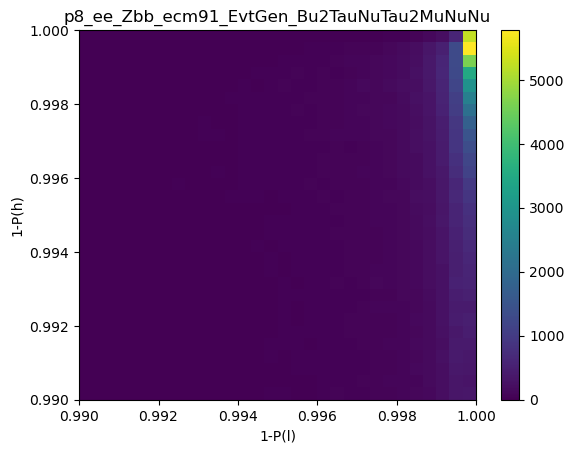

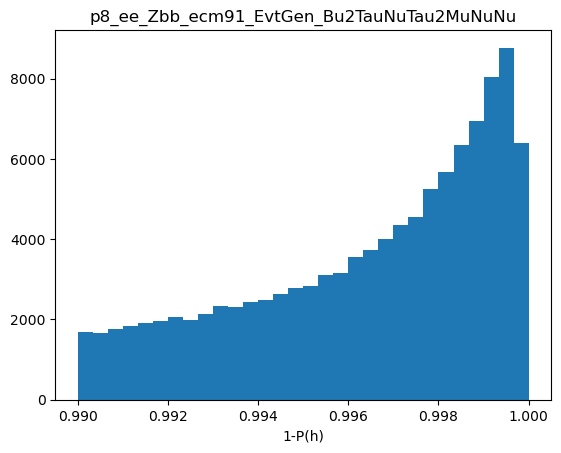

In [7]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.99,1),(0.99,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range=(0.99,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

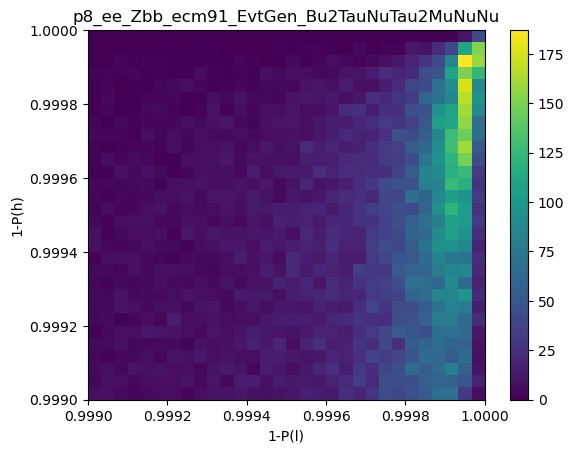

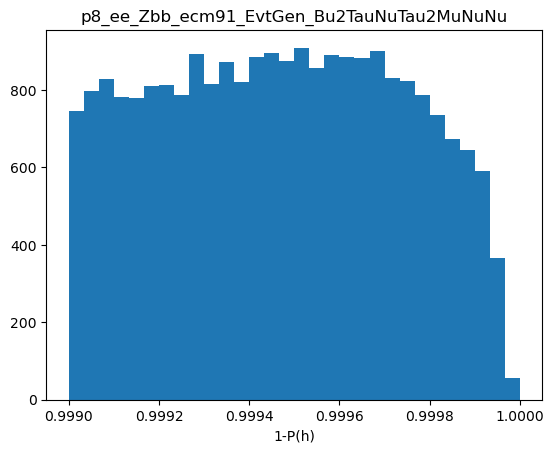

In [8]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.999,1),(0.999,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range=(0.999,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()



#Note plotting P(s) distribution is a bit unhelpful since already cut on P(l) and P(h) both <0.1

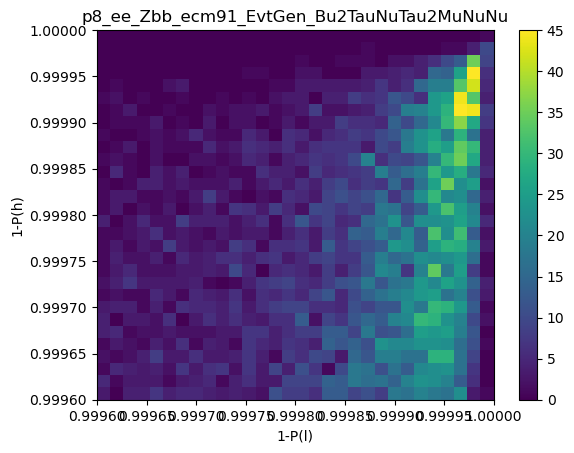

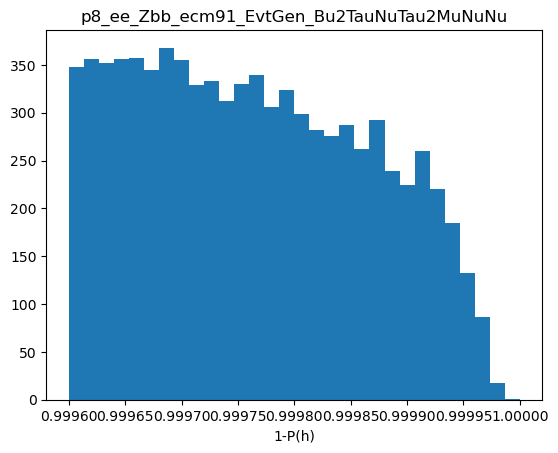

In [9]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.9996,1),(0.9996,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30,range=(0.9996,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()



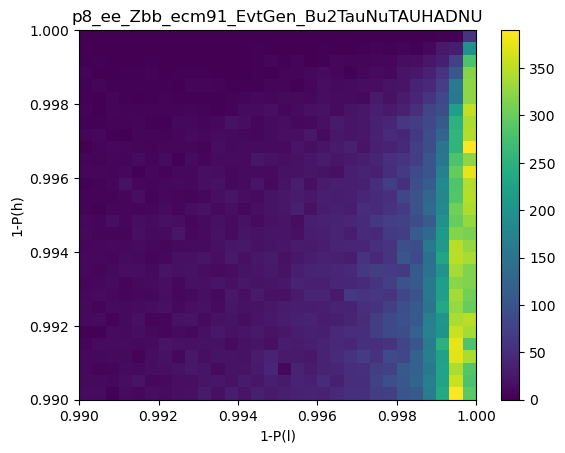

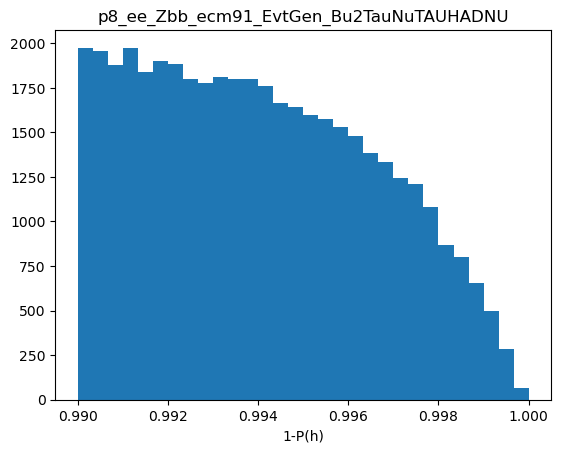

In [10]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30, range = [(0.99,1),(0.99,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30,range=(0.99,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()



## 4. Preselection (incl. nlept cut) + BDT

In [11]:
outputpath_nlept_veto   = basic_functions.set_outputpath(os.path.join(inputpath,"dataframes_cutEVT_hemisEmin_nLept----0","bdtlh_099cut"))

full_df_decay_nlept = {}
full_df_decay_nlept_cut = {}

for decay in samples:
    dataframes_nlept = []
    decay_outpath_nlept = basic_functions.set_outputpath(os.path.join(outputpath_nlept_veto,f'{decay}'))
    for filename_nlept in os.listdir(decay_outpath_nlept):
        if filename_nlept.endswith(".pkl"):
            filepath_nlept = os.path.join(decay_outpath_nlept, filename_nlept)
            df_nlept = pd.read_pickle(filepath_nlept)
            #df_nlept = df_nlept[((1-df_nlept["bdt_score_0"])>0.99965)&((1-df_nlept["bdt_score_1"])>0.99965)]
            dataframes_nlept.append(df_nlept)
    
    full_df_nlept = pd.concat(dataframes_nlept, ignore_index=True)
    full_df_decay_nlept[decay] = full_df_nlept
    full_df_decay_nlept_cut[decay] =  full_df_nlept[((1-full_df_nlept["bdt_score_0"])>0.99965)&((1-full_df_nlept["bdt_score_1"])>0.99965)]

In [12]:
print(f'Total efficinecy Tau2MuNuNu: {len(full_df_decay_nlept_cut["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"])/1000000}')
print(f'Total efficinecy TAUHADNU: {len(full_df_decay_nlept_cut["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"])/10000000}')

Total efficinecy Tau2MuNuNu: 0.001521
Total efficinecy TAUHADNU: 6.5e-06


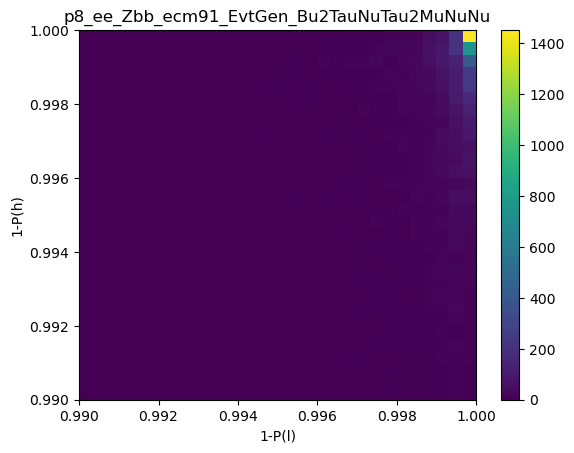

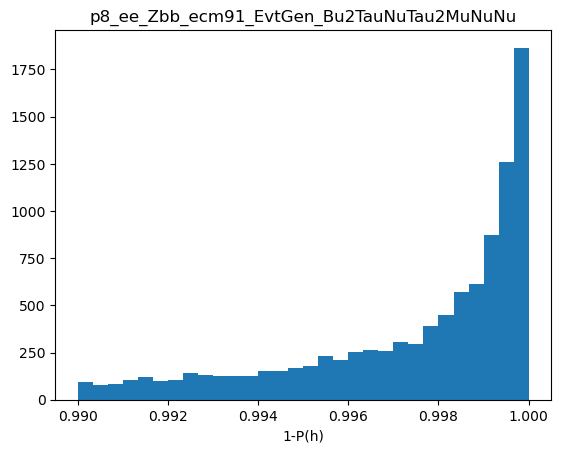

In [13]:
plt.hist2d(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.99,1),(0.99,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30,range = (0.99,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

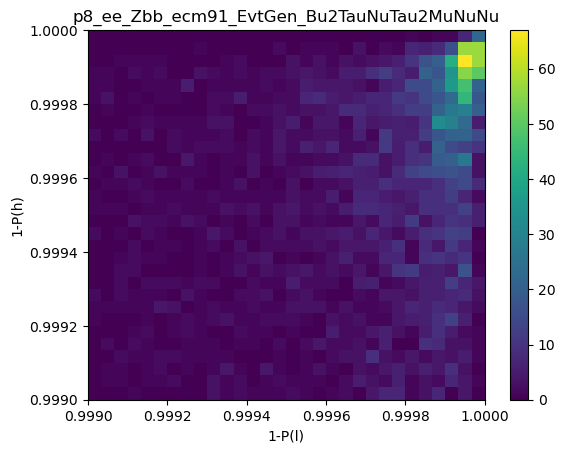

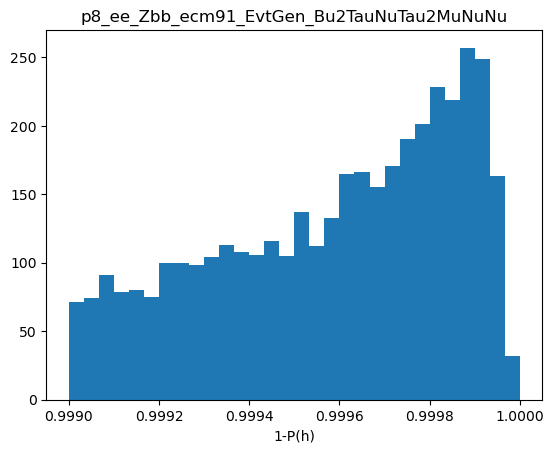

In [14]:
plt.hist2d(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.999,1),(0.999,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30,range = (0.999,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()



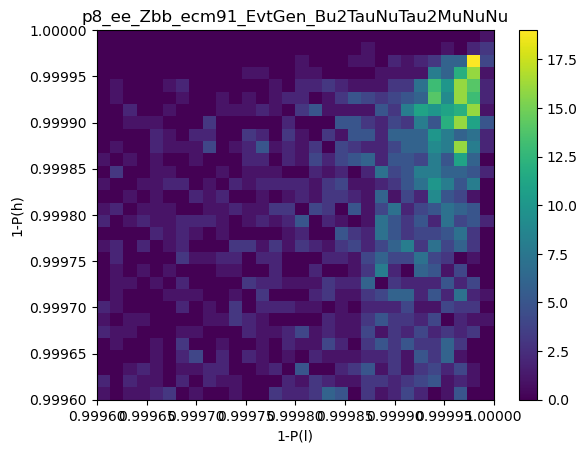

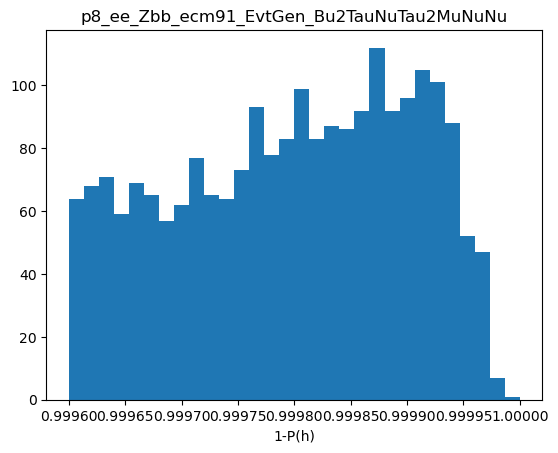

In [15]:
plt.hist2d(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_0, 1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30, range = [(0.9996,1),(0.9996,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

plt.hist(1-full_df_decay_nlept["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"].bdt_score_1,bins=30,range=(0.9996,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu")
plt.show()

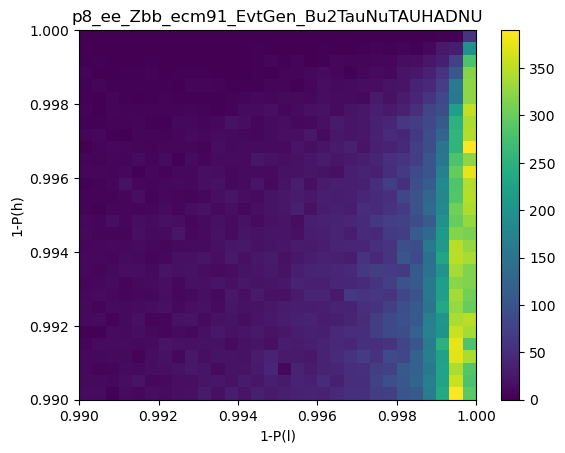

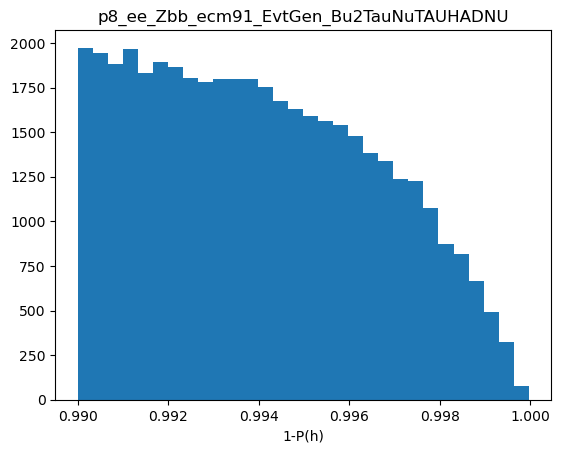

In [16]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30, range = [(0.99,1),(0.99,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30)
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()


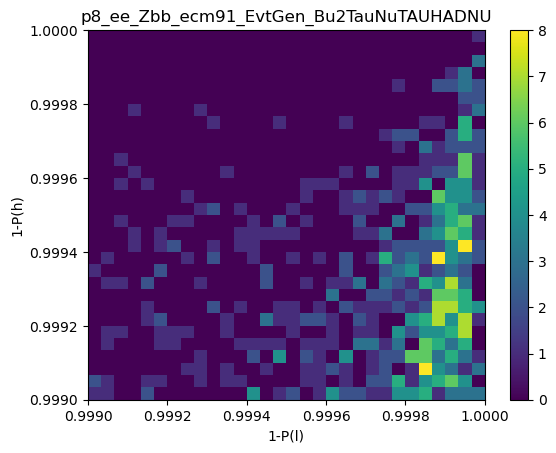

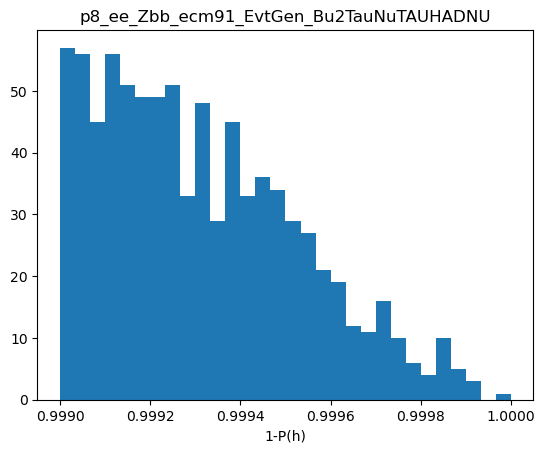

In [17]:
plt.hist2d(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_0, 1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30, range = [(0.999,1),(0.999,1)])
plt.xlabel("1-P(l)")
plt.ylabel("1-P(h)")
plt.colorbar()
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()

plt.hist(1-full_df_decay["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU"].bdt_score_1,bins=30, range=(0.999,1))
plt.xlabel("1-P(h)")
plt.title("p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU")
plt.show()
